In [1]:
# ── Cell 1: Imports & Config ──────────────────────────────────────────────────
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, gc, warnings
warnings.filterwarnings('ignore')
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
 
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, matthews_corrcoef,
                              confusion_matrix, ConfusionMatrixDisplay)
 
os.makedirs('../models', exist_ok=True)
os.makedirs('../data',   exist_ok=True)
 
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256
EPOCHS     = 40
LR         = 5e-4
SEQ_LEN    = 8       # treat each feature vector as a sequence of 8 steps
CARDINALITY = 4      # ResNeXt parallel paths
 
print(f"Device : {DEVICE}")
 

Device : cpu


In [2]:
# ── Cell 2: Load EARN+ Features ───────────────────────────────────────────────
 
Z_train = np.load('../data/Z_train_earn.npy').astype(np.float32)
Z_test  = np.load('../data/Z_test_earn.npy').astype(np.float32)
y_train = np.load('../data/y_train.npy').astype(np.int64)
y_test  = np.load('../data/y_test.npy').astype(np.int64)
 
INPUT_DIM = Z_train.shape[1]   # auto-reads whatever shape Notebook 3 output
 
print(f"Train features : {Z_train.shape}")
print(f"Test features  : {Z_test.shape}")
print(f"Input dim      : {INPUT_DIM}")
print(f"Class split    : fraud={y_train.sum():,}  legit={(y_train==0).sum():,}")

Train features : (329932, 50)
Test features  : (82484, 50)
Input dim      : 50
Class split    : fraud=164,966  legit=164,966


In [3]:
# ── Cell 3: ResNeXt Block Definition ─────────────────────────────────────────
#
# ResNeXt uses CARDINALITY parallel paths (grouped convolution idea,
# applied to linear layers). Each path learns a different representation,
# then they are summed — more expressive than a single wide layer.
 
class ResNeXtBlock(nn.Module):
    def __init__(self, in_dim, out_dim, cardinality=CARDINALITY):
        super().__init__()
        assert out_dim % cardinality == 0, "out_dim must be divisible by cardinality"
        group_dim = out_dim // cardinality
 
        # Parallel grouped paths
        self.paths = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_dim, group_dim),
                nn.BatchNorm1d(group_dim),
                nn.ReLU(),
                nn.Linear(group_dim, group_dim),
                nn.BatchNorm1d(group_dim)
            ) for _ in range(cardinality)
        ])
 
        # Projection shortcut
        self.shortcut = (
            nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        )
        self.relu = nn.ReLU()
 
    def forward(self, x):
        # Concatenate all parallel path outputs, then add skip connection
        path_outs = torch.cat([p(x) for p in self.paths], dim=-1)
        return self.relu(path_outs + self.shortcut(x))
 
 
class ResNeXtExtractor(nn.Module):
    """Stacked ResNeXt blocks producing a 64-dim transaction embedding."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            ResNeXtBlock(input_dim, 128),
            ResNeXtBlock(128, 128),
            ResNeXtBlock(128, 64),
            ResNeXtBlock(64,  64)
        )
 
    def forward(self, x):
        return self.net(x)
 
print("ResNeXt defined.")

ResNeXt defined.


In [4]:
# ── Cell 4: Attention-GRU Definition ─────────────────────────────────────────
#
# We reshape each 64-dim embedding into SEQ_LEN steps of 8 dims each.
# The GRU learns temporal dependencies across these steps.
# The attention layer then WEIGHS which steps matter most — this is
# what gives resilience to concept drift (evolving fraud patterns).
 
class SelfAttentionGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, seq_len=SEQ_LEN):
        super().__init__()
        self.seq_len   = seq_len
        self.step_dim  = input_dim // seq_len  # features per step
 
        self.gru = nn.GRU(
            input_size=self.step_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=False
        )
 
        # Attention: learns a scalar weight per GRU timestep
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
 
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        # x: (batch, input_dim) → reshape to (batch, seq_len, step_dim)
        x = x.view(x.size(0), self.seq_len, self.step_dim)
 
        gru_out, _ = self.gru(x)                         # (batch, seq_len, hidden)
        attn_scores = self.attention(gru_out)             # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_scores, dim=1) # normalise over time
        context = (attn_weights * gru_out).sum(dim=1)    # weighted sum → (batch, hidden)
 
        return self.classifier(context).squeeze(1), attn_weights.squeeze(-1)
 
print("Attention-GRU defined.")
 

Attention-GRU defined.


In [5]:
# ── Cell 5: Build Full Attention-RXT-J Pipeline ───────────────────────────────
 
class AttentionRXTJ(nn.Module):
    """
    Full hybrid classifier:
      ResNeXt → 64-dim embedding
      Attention-GRU → temporal scoring with attention weights
    """
    def __init__(self, input_dim, seq_len=SEQ_LEN):
        super().__init__()
        self.resnext   = ResNeXtExtractor(input_dim)
        self.attn_gru  = SelfAttentionGRU(input_dim=64, seq_len=seq_len)
 
    def forward(self, x):
        embedding        = self.resnext(x)                  # (batch, 64)
        score, attn_w    = self.attn_gru(embedding)         # (batch,), (batch, seq_len)
        return score, attn_w
 
model = AttentionRXTJ(INPUT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nAttention-RXT-J model built.")
print(f"Trainable parameters: {total_params:,}")


Attention-RXT-J model built.
Trainable parameters: 105,794


In [6]:
# ── Cell 6: Prepare DataLoaders ───────────────────────────────────────────────
 
# Class weights to handle any residual imbalance
fraud_count = y_train.sum()
legit_count = (y_train == 0).sum()
pos_weight  = torch.tensor([legit_count / fraud_count], dtype=torch.float32).to(DEVICE)
print(f"BCELoss pos_weight: {pos_weight.item():.4f}")
 
train_ds = TensorDataset(
    torch.FloatTensor(Z_train),
    torch.FloatTensor(y_train.astype(np.float32))
)
test_ds  = TensorDataset(
    torch.FloatTensor(Z_test),
    torch.FloatTensor(y_test.astype(np.float32))
)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
 
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

BCELoss pos_weight: 1.0000
Train batches: 1289 | Test batches: 323


In [7]:
# ── Cell 7: Training Loop ─────────────────────────────────────────────────────
 
optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
# Use raw logits for BCEWithLogitsLoss — disable sigmoid in classifier
# (redefine the last layer to remove sigmoid for training)
model.attn_gru.classifier[-1] = nn.Identity()  # remove sigmoid; apply in inference
 
train_losses, val_aucs = [], []
 
print(f"\nTraining Attention-RXT-J for {EPOCHS} epochs...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val AUC':>8} | {'LR':>8}")
print("-" * 45)
 
best_auc   = 0.0
best_state = None
 
for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
 
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
 
    # ── Validate ──
    model.eval()
    all_probs = []
    with torch.no_grad():
        for xb, _ in test_loader:
            logits, _ = model(xb.to(DEVICE))
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
 
    auc = roc_auc_score(y_test, all_probs)
    val_aucs.append(auc)
 
    if auc > best_auc:
        best_auc   = auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
 
    if (epoch + 1) % 5 == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(f"{epoch+1:>6} | {avg_loss:>10.4f} | {auc:>8.4f} | {lr_now:>8.6f}")
 
print(f"\nBest Val AUC: {best_auc:.4f}")
 
# Restore best weights
model.load_state_dict(best_state)
 


Training Attention-RXT-J for 40 epochs...
 Epoch | Train Loss |  Val AUC |       LR
---------------------------------------------
     5 |     0.2012 |   0.9545 | 0.000481
    10 |     0.1861 |   0.9141 | 0.000427
    15 |     0.1780 |   0.9177 | 0.000346
    20 |     0.1680 |   0.9021 | 0.000250
    25 |     0.1598 |   0.8163 | 0.000154
    30 |     0.1535 |   0.8782 | 0.000073
    35 |     0.1512 |   0.9470 | 0.000019
    40 |     0.1495 |   0.9201 | 0.000000

Best Val AUC: 0.9682


<All keys matched successfully>

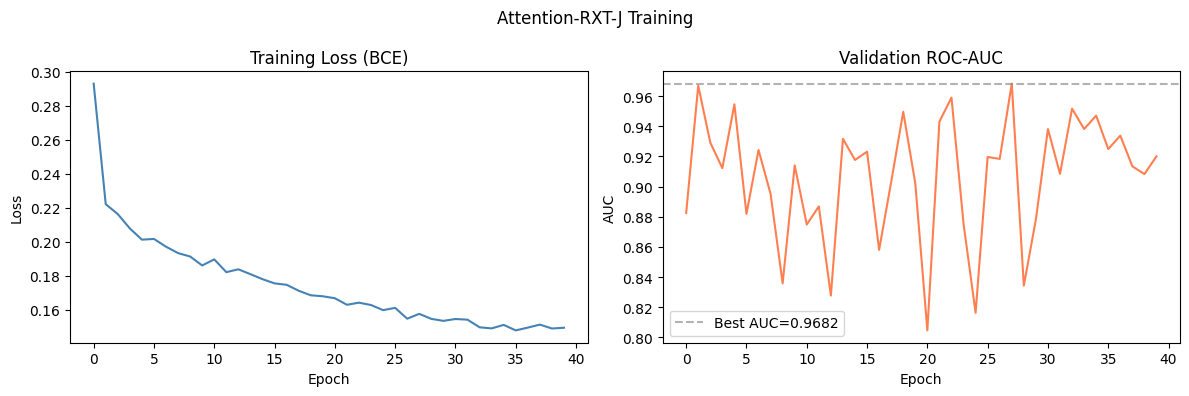

In [8]:
# ── Cell 8: Training Curves ────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title('Training Loss (BCE)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
 
axes[1].plot(val_aucs, color='coral')
axes[1].axhline(best_auc, color='gray', linestyle='--', alpha=0.6,
                label=f'Best AUC={best_auc:.4f}')
axes[1].set_title('Validation ROC-AUC')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend()
 
plt.suptitle('Attention-RXT-J Training', fontsize=12)
plt.tight_layout()
plt.savefig('../data/training_curves.png')
plt.show()
 
 

  ATTENTION-RXT-J EVALUATION RESULTS
  ROC-AUC Score : 0.9682
  MCC Score     : 0.7972  (target > 0.7)

              precision    recall  f1-score   support

       Legit       0.96      0.82      0.89     41242
       Fraud       0.84      0.97      0.90     41242

    accuracy                           0.89     82484
   macro avg       0.90      0.89      0.89     82484
weighted avg       0.90      0.89      0.89     82484



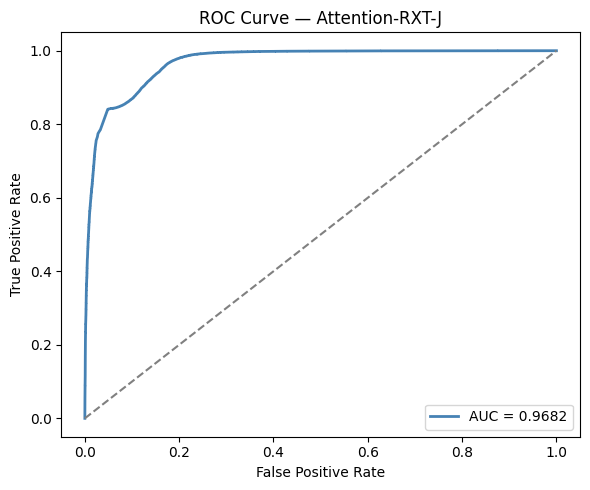

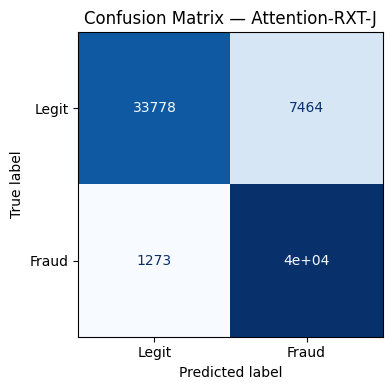

In [9]:
# ── Cell 9: Full Evaluation ────────────────────────────────────────────────────
 
model.eval()
all_probs, all_preds = [], []
 
with torch.no_grad():
    for xb, _ in test_loader:
        logits, _ = model(xb.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
 
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
 
# ── Metrics ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, all_probs)
mcc = matthews_corrcoef(y_test, all_preds)
 
print("=" * 50)
print("  ATTENTION-RXT-J EVALUATION RESULTS")
print("=" * 50)
print(f"  ROC-AUC Score : {auc:.4f}")
print(f"  MCC Score     : {mcc:.4f}  (target > 0.7)")
print()
print(classification_report(y_test, all_preds,
                             target_names=['Legit', 'Fraud']))
 
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Attention-RXT-J')
plt.legend()
plt.tight_layout()
plt.savefig('../data/roc_curve.png')
plt.show()
 
# Confusion Matrix
cm = confusion_matrix(y_test, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Attention-RXT-J')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()
 

In [10]:
# ── Cell 10: Isolation Forest — Anomaly Scoring ───────────────────────────────
#
# IFM assigns anomaly scores to rare outlier transactions that are
# difficult for the main classifier (e.g. novel fraud patterns).
# Combined with the main model score in Cell 11.
 
print("\nTraining Isolation Forest on EARN+ features...")
ifm = IsolationForest(
    n_estimators=200,
    contamination=0.05,    # expected fraud rate ~5%
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
# Train on fraud samples only — learns the "fraud manifold"
fraud_idx = np.where(y_train == 1)[0]
ifm.fit(Z_train[fraud_idx])
 
# Score test set — more negative = more anomalous
ifm_scores_raw = ifm.score_samples(Z_test)
 
# Normalise to [0,1] — higher = more anomalous (fraud-like)
ifm_min, ifm_max = ifm_scores_raw.min(), ifm_scores_raw.max()
ifm_scores = 1 - (ifm_scores_raw - ifm_min) / (ifm_max - ifm_min)
 
print(f"IFM score range: {ifm_scores.min():.3f} – {ifm_scores.max():.3f}")


Training Isolation Forest on EARN+ features...
IFM score range: 0.000 – 1.000


In [11]:
# ── Cell 11: Combined Risk Score ──────────────────────────────────────────────
#
# Final risk score = weighted combination:
#   W_model = 0.75  (main Attention-RXT-J probability)
#   W_ifm   = 0.25  (isolation forest anomaly signal)
# These weights feed into Jaya optimization in Notebook 5.
 
W_MODEL = 0.75
W_IFM   = 0.25
 
risk_scores = W_MODEL * all_probs + W_IFM * ifm_scores
risk_preds  = (risk_scores > 0.5).astype(int)
 
combined_auc = roc_auc_score(y_test, risk_scores)
combined_mcc = matthews_corrcoef(y_test, risk_preds)
 
print("\n" + "=" * 50)
print("  COMBINED RISK SCORE RESULTS")
print("=" * 50)
print(f"  Model-only AUC   : {auc:.4f}")
print(f"  Combined AUC     : {combined_auc:.4f}   ← should be >= model-only")
print(f"  Combined MCC     : {combined_mcc:.4f}")
print()
print(classification_report(y_test, risk_preds,
                             target_names=['Legit', 'Fraud']))


  COMBINED RISK SCORE RESULTS
  Model-only AUC   : 0.9682
  Combined AUC     : 0.9671   ← should be >= model-only
  Combined MCC     : 0.7993

              precision    recall  f1-score   support

       Legit       0.95      0.83      0.89     41242
       Fraud       0.85      0.96      0.90     41242

    accuracy                           0.90     82484
   macro avg       0.90      0.90      0.90     82484
weighted avg       0.90      0.90      0.90     82484



In [12]:
# ── Cell 12: Save Everything for Notebook 5 ───────────────────────────────────
 
torch.save(model.state_dict(), '../models/attention_rxtj.pt')
joblib.dump(ifm,               '../models/isolation_forest.pkl')
 
np.save('../data/risk_scores.npy',  risk_scores)
np.save('../data/model_probs.npy',  all_probs)
np.save('../data/ifm_scores.npy',   ifm_scores)
np.save('../data/y_test.npy',       y_test)
 
print("\n✓ Saved:")
print("   models/attention_rxtj.pt")
print("   models/isolation_forest.pkl")
print("   data/risk_scores.npy   ← combined scores for Notebook 5")
print("   data/model_probs.npy")
print("   data/ifm_scores.npy")
print(f"\nFinal Combined AUC : {combined_auc:.4f}")
print(f"Final MCC          : {combined_mcc:.4f}")
print("\nNotebook 4 complete — ready for Jaya optimisation in Notebook 5.")


✓ Saved:
   models/attention_rxtj.pt
   models/isolation_forest.pkl
   data/risk_scores.npy   ← combined scores for Notebook 5
   data/model_probs.npy
   data/ifm_scores.npy

Final Combined AUC : 0.9671
Final MCC          : 0.7993

Notebook 4 complete — ready for Jaya optimisation in Notebook 5.
